In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [50]:
df = pd.read_csv("C:/Users/GAYATHARI/Downloads/cleaned_superstore_dataset.xls")

In [51]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Day
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
 18  Year    

In [53]:
df.describe()

,Row ID,Postal Code,Sales,Year,Month,Day
count,9800.000000,9789.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,55273.322403,230.769059,2016.724184,7.818469,15.486837
std,2829.160653,32041.223413,626.651875,1.123984,3.281905,8.753733
min,1.000000,1040.000000,0.444000,2015.000000,1.000000,1.000000
25%,2450.750000,23223.000000,17.248000,2016.000000,5.000000,8.000000
50%,4900.500000,58103.000000,54.490000,2017.000000,9.000000,16.000000
75%,7350.250000,90008.000000,210.605000,2018.000000,11.000000,23.000000
max,9800.000000,99301.000000,22638.480000,2018.000000,12.000000,31.000000


In [54]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Day               0
dtype: int64

In [55]:
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())


Total Sales: 2261536.7827
Average Sales: 230.76905945918367


In [56]:
df['Category'].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

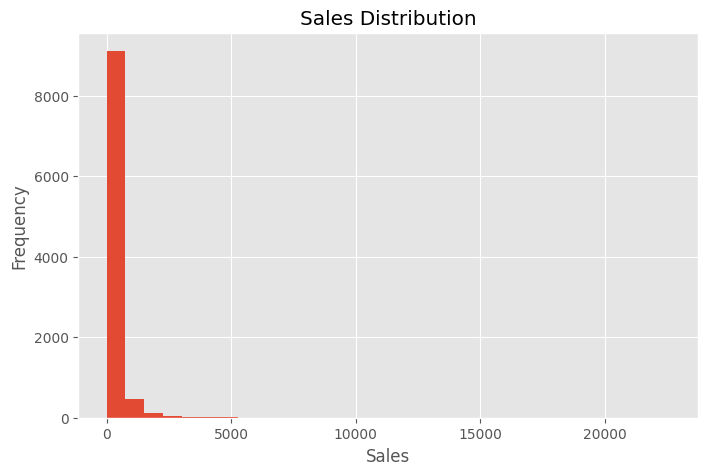

In [57]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

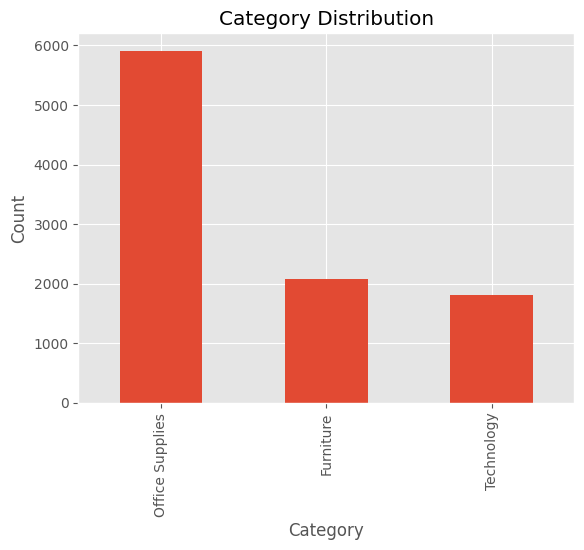

In [58]:
df['Category'].value_counts().plot(kind='bar')

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [59]:
!pip install pandasql

In [60]:
from pandasql import sqldf
import pandas as pd
from pandasql import sqldf

In [61]:
pysqldf = lambda q: sqldf(q, globals())

In [62]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Day'],
      dtype='object')


In [63]:
df.columns = df.columns.str.strip()

df.columns = df.columns.str.replace(' ', '_')

df.columns = df.columns.str.replace('-', '_')

print(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Year', 'Month', 'Day'],
      dtype='object')


In [64]:
pysqldf = lambda q: sqldf(q, globals())

In [65]:
#Q1
query = """
SELECT Product_Name, SUM(Sales) as Total_Sales
FROM df
GROUP BY Product_Name
ORDER BY Total_Sales DESC
LIMIT 5
"""

pysqldf(query)

,Product_Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479


In [66]:
#Q2
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Month'] = df['Order_Date'].dt.month

query = """
SELECT Month, SUM(Sales) as Monthly_Sales
FROM df
GROUP BY Month
ORDER BY Month
"""

monthly_sales = pysqldf(query)

monthly_sales

,Month,Monthly_Sales
0,1,94291.6296
1,2,59371.1154
2,3,197573.5872
3,4,136283.0006
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
7,8,157315.9270
8,9,300103.4117
9,10,199496.2947


In [85]:
#Q3
query = """
SELECT Category,
       SUM(Sales) AS Total_Sales
FROM df
GROUP BY Category
ORDER BY Total_Sales DESC
"""

result = pysqldf(query)

print(result)

          Category  Total_Sales
0       Technology  827455.8730
1        Furniture  728658.5757
2  Office Supplies  705422.3340


In [72]:
df.columns = df.columns.str.strip()

df.columns = df.columns.str.replace(' ', '_')

print(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Year', 'Month', 'Day'],
      dtype='object')


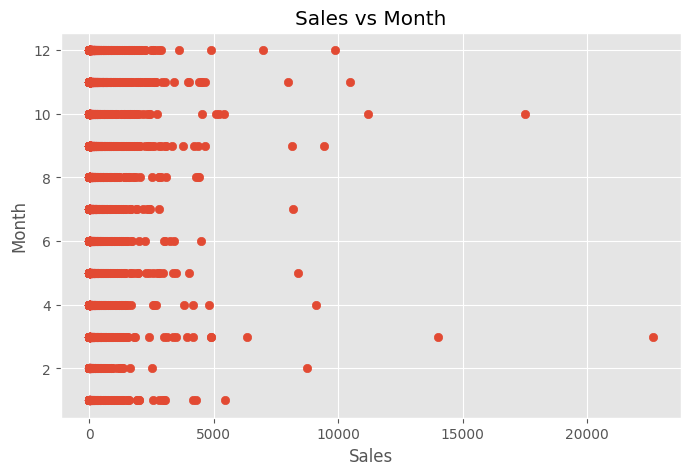

In [79]:
plt.figure(figsize=(8,5))

plt.scatter(df['Sales'], df['Month'])

plt.xlabel("Sales")
plt.ylabel("Month")
plt.title("Sales vs Month")

plt.show()

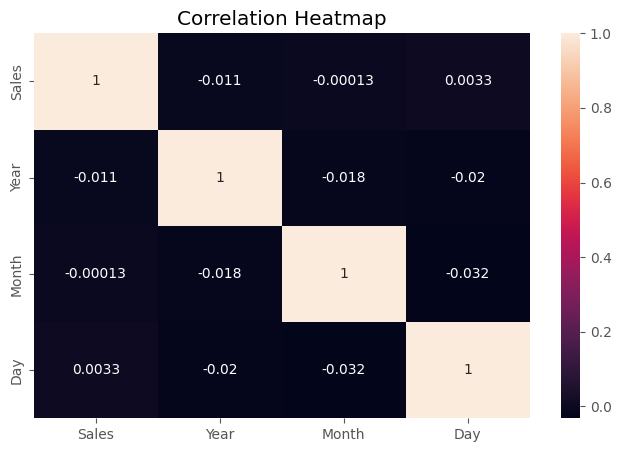

In [80]:
corr = df[['Sales','Year','Month','Day']].corr()

plt.figure(figsize=(8,5))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

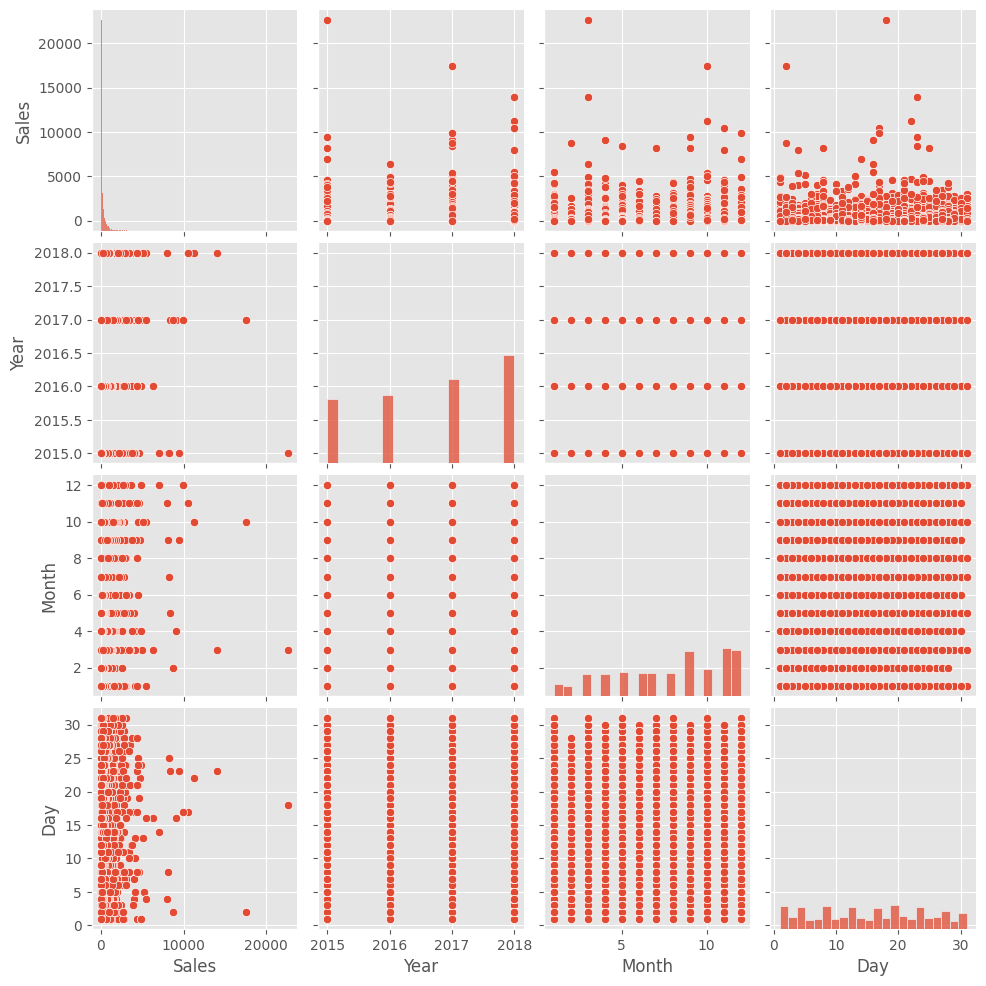

In [81]:
sns.pairplot(df[['Sales','Year','Month','Day']])

plt.show()

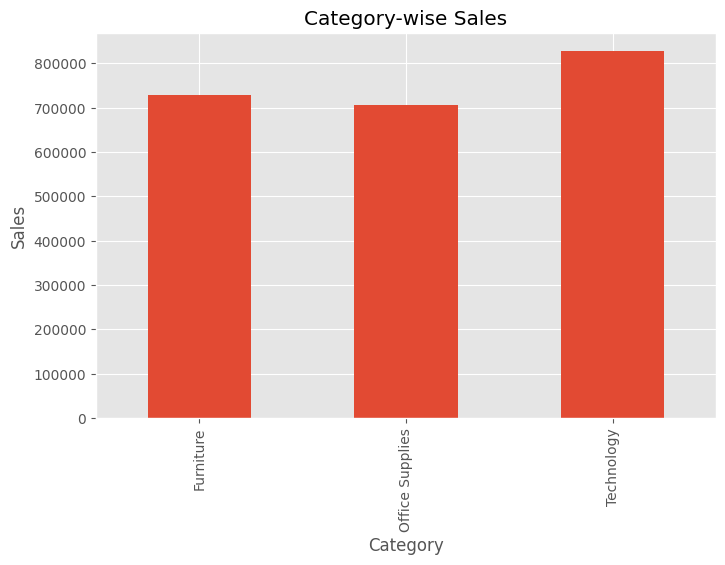

In [82]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', figsize=(8,5))

plt.title("Category-wise Sales")

plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

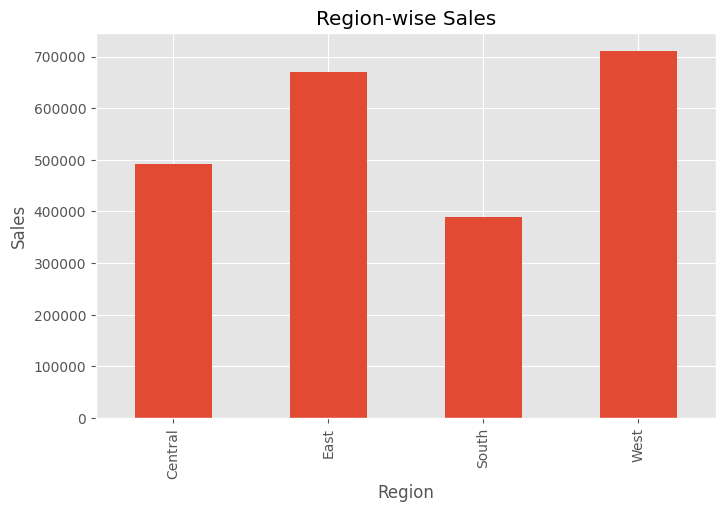

In [83]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar', figsize=(8,5))

plt.title("Region-wise Sales")

plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [ ]:
#INSIGHTS
1. Sales vary across different months.
2. Technology category contributes high sales.
3. Some regions generate more sales than others.
4. Correlation heatmap shows relationships among numerical variables.